# How GPU's work, an explainer using the Mandelbrot set

Every day pretty much either uses or hears about the mythical GPU, the Graphics Processing Unit. It's the thing that makes your games run faster, your video render faster, and your machine learning models train faster. But how does it do that? What makes it different from a CPU?

We will do a quick explainer which should give you a good intuition using the [Mandelbrot set](https://www.quantamagazine.org/the-quest-to-decode-the-mandelbrot-set-maths-famed-fractal-20240126/). The Mandelbrot set is a fractal, a set of complex numbers that when iterated through a function, either diverges to infinity or stays bounded, it is the boundary between these two regions. The Mandelbrot set is a great example to use because it's a simple function that can be parallelized easily.

## A quick diversion into parallelism

In my university days, I had a quick course on parallelism, and we were asked how we could parallelize the computation of the Mandelbrot set. The answer is simple, we can calculate each pixel independently, since at its core, calculating the the set involves applying a function to each complex number to determine if it belongs to the set or not.

Back then the approach I followed was to divide the image into an $n x n$ grid and assign each grid to a separate networked computer, which would then calculate the pixels in that grid, and write results to a network shared file (this was back in the day where RPC was barely a thing). This is a simple form of parallelism, and it's called [embarrassingly parallel](https://en.wikipedia.org/wiki/Embarrassingly_parallel).

Most GPU computations are embarrassingly parallel, and this is why they are so good at simple parallelism workloads. They have thousands of cores, and each core can act independently to compute a fragment of the workload.

They are adept at machine learning and AI workloads equally because most of the computations in these fields are matrix multiplications, which can be parallelized easily.

## The Mandelbrot set

The Mandelbrot set is defined by the following function:

$$
f(z) = z^2 + c
$$

where $z$ is a complex number, and $c$ is a constant complex number. We can iterate this function, and if the magnitude of $z$ is greater than 2, then we can say that the function diverges to infinity. If it doesn't, then it stays bounded. The Mandelbrot set is the boundary between these two regions.

Further below we will show a rendered image of the Mandelbrot set, but first, let's write a simple Python function to calculate it.

## Calculating the Mandelbrot set with no parallelism

Let's start by writing a simple, naive function to calculate the Mandelbrot set. This function uses *no* parallelism, and it's a simple for loop that iterates over each pixel in the image and calculates each pixel using the CPU only. It basically iterates over columns and rows and for each it computes whether that particular point diverges or not as nested loops.

For a width of 500 and height of 500, this function will compute $250000$ pixels, for a width of 1000 and height of 1000, it will compute $1000000$ pixels, and so on. The time taken for this function to run increase as $O(n^2)$ where $n$ is the width or height of the image.

In [1]:
def compute_mandelbrot_iterations(width, height, max_iter):
    real_min, real_max = -2, 1
    imag_min, imag_max = -1.5, 1.5
    real_step = (real_max - real_min) / (width - 1)
    imag_step = (imag_max - imag_min) / (height - 1)
    
    # Initialize a 2D list to hold iteration counts.
    iter_counts = [[0 for _ in range(width)] for _ in range(height)]
    
    for j in range(height):
        imag = imag_min + j * imag_step
        for i in range(width):
            real = real_min + i * real_step
            c = complex(real, imag)
            z = 0j
            count = 0
            while count < max_iter:
                z = z * z + c
                # Check divergence: if |z|^2 > 4 then break.
                if (z.real * z.real + z.imag * z.imag) > 4:
                    break
                count += 1
            iter_counts[j][i] = count
    
    return iter_counts

## Calculating the Mandelbrot set with parallelism

While the above function is simple, it is not the most efficient. Because it is basically a big matrix operation (an image *is* a matrix), we can parallelize it easily using a number of frameworks which offer matrix operations. Let's see how we would do this using a number of libraries.

For this example, we will show how to achieve the above using `numpy`, `pytorch` and Apple's `mlx`. They all offer a similar API, and can be used virtually interchangeably. They offer a set of functionality which allows you to perform matrix operations on either the CPU and GPU:

- Vectorized Operations: They all let you perform elementwise operations on entire arrays/tensors without explicit loops, which boosts performance.
- Broadcasting: NumPy, PyTorch, and MLX support broadcasting, allowing operations on arrays of different shapes—great for aligning matrices without manual reshaping.
- Optimized Backends: Under the hood, they rely on highly optimized C/C++ libraries (like BLAS/LAPACK or Apple’s Accelerate framework for MLX) to perform computations quickly.
- Multi-dimensional Data Handling: They all offer robust support for multi-dimensional arrays (or tensors), making them well-suited for tasks ranging from basic linear algebra to complex machine learning computations.


### Numpy

Let's start with an implementation of the `compute_mandelbrot_iterations` function using `numpy`, entirely with array (or matrix) operations.

In [2]:
import numpy as np

def compute_mandelbrot_numpy(width:int = 500, height:int = 500, max_iter:int = 30) -> np.ndarray:
    # Create linearly spaced real and imaginary parts and generate a complex grid.
    real = np.linspace(-2, 1, width)
    imag = np.linspace(-1.5, 1.5, height)
    X, Y = np.meshgrid(real, imag, indexing='xy')
    c = X + 1j * Y

    # Initialize z and an array to hold the iteration counts
    z = np.zeros_like(c)
    iter_counts = np.zeros(c.shape, dtype=np.int32)

    for _ in range(max_iter):
        # Create a mask for points that have not yet diverged
        mask = np.abs(z) < 4
        if not mask.any():
            break
        
        # Update z and iteration counts only where |z| < 4
        z = np.where(mask, z * z + c, z)
        iter_counts = np.where(mask, iter_counts + 1, iter_counts)

    return iter_counts

This function starts by generating a grid of complex numbers using matrix operations, which is key for parallel computation. It first creates two linearly spaced arrays for the real and imaginary parts using `np.linspace`, and then builds two 2D grids with `np.meshgrid` — one for the real values and one for the imaginary values. These grids are combined into a single complex grid `c` (where each element is of the form `x + 1j * y`), and this process happens all at once without the need for explicit loops, leveraging NumPy’s vectorized operations.

Next, the code initializes two arrays of the same shape as `c`: one for the iterative values `z` (starting at zero) and one to keep track of the iteration counts. The main computation occurs in a loop where, in each iteration, the code computes the absolute value of every element in `z` simultaneously using `np.abs(z)` and creates a boolean mask that identifies the elements where `|z| < 4`. This mask is then used to update `z` and `i`ter_counts` in one go via `np.where`, ensuring that only the elements that haven't diverged (i.e., where the condition holds) are updated.

Because these operations — creating the grid, computing absolute values, applying the mask, and updating arrays — are all performed on entire arrays at once, they are handled in parallel by optimized C code under the hood. This eliminates the need for slow, explicit Python loops, which is why such an approach is highly efficient for intensive computations like generating the Mandelbrot set. The combination of vectorized operations and conditional updates not only makes the code concise but also allows the underlying hardware to execute many operations concurrently, resulting in much faster computation.

### PyTorch

Now let us do the same but with the `pytorch` library, except for the line `c = X.t() + 1j * Y.t()`, the code is almost identical to the `numpy` implementation. The `t()` function is used to transpose the matrix, and the `+` and `*` operators are overloaded to perform elementwise addition and multiplication, respectively. This allows us to create the complex grid `c` in a single line, just like in the NumPy version.

```{admonition} Tip
:class: tip, dropdown

The reason you see a transpose in PyTorch is because its grid creation defaults to a different dimension ordering than NumPy's. In NumPy, when you use `np.meshgrid` with `indexing='xy'`, the resulting arrays have the first dimension corresponding to the y-axis and the second to the x-axis, matching common image coordinate conventions. PyTorch's `torch.meshgrid`, on the other hand, typically returns tensors where the dimensions are swapped relative to that layout. By transposing (`.t()`) the PyTorch tensors, you align the dimensions so that the complex grid `c` ends up with the same arrangement as in NumPy. This ensures that each element in `c` correctly corresponds to the intended coordinate in the complex plane.
```

In [3]:
import torch

def compute_mandelbrot_torch(width:int = 500, height:int = 500, max_iter:int = 30, device:str = 'cpu') -> torch.Tensor:
    real = torch.linspace(-2, 1, steps=width, device=device)
    imag = torch.linspace(-1.5, 1.5, steps=height, device=device)
    X, Y = torch.meshgrid(real, imag, indexing='xy')
    c = X.t() + 1j * Y.t()
    
    z = torch.zeros_like(c)
    iter_counts = torch.zeros(c.shape, device=device, dtype=torch.int32)
    
    for _ in range(max_iter):
        mask = torch.abs(z) < 4
        if not mask.any():
            break
        
        z = torch.where(mask, z * z + c, z)
        iter_counts = torch.where(mask, iter_counts + 1, iter_counts)
    
    return iter_counts

Because we are using PyTorch tensors, we can offload the workload onto a GPU by setting the `device` parameter to `'cuda'` or `'mps'`. This tells PyTorch to use the GPU for all subsequent operations, which will significantly speed up the computation. The rest of the code remains the same, with the same vectorized operations and conditional updates as in the NumPy version.

The difference being that when using the GPU, the operations will run concurrently on the GPU cores, which are optimized for parallel computation. For example, when running `z = torch.where(mask, z * z + c, z)` on a GPU, each element in `z`, `mask`, and `c` can be processed simultaneously by different cores, allowing for massive speedups compared to sequential execution on a CPU. Effectivelly we will be "painting" the Mandelbrot set in one single operation rather than pixel by pixel.

### Apple's MLX

Apple's MLX offers an API which is virtually the same as PyTorch and NumPy, and it can be used interchangeably with them. The only difference is that it is optimized for Apple hardware, and it can be used on Apple Silicon.

In [4]:
import mlx.core as mx

def compute_mandelbrot_mlx(width:int = 500, height:int = 500, max_iter:int = 30) -> mx.array:
    real = mx.linspace(-2, 1, width)
    imag = mx.linspace(-1.5, 1.5, height)
    X, Y = mx.meshgrid(real, imag, indexing='xy')
    c = X + 1j * Y

    z = mx.zeros_like(c)
    iter_counts = mx.zeros(c.shape, dtype=mx.int32)

    for _ in range(max_iter):
        mask = mx.abs(z) < 4
        if not mask.any():
            break

        z = mx.where(mask, z * z + c, z)
        iter_counts = mx.where(mask, iter_counts + 1, iter_counts)

    return iter_counts

## Putting it all together

Let's put all the above together and render the Mandelbrot set with each different method. Each of `compute_mandelbrot_*` returns a 2D array of integers, where each integer represents the number of iterations it took for that pixel to diverge. We will then use `matplotlib` to render the image.

In [5]:
mps_available = torch.backends.mps.is_available()

width, height = 500, 500
max_iter = 30

iter_counts = []

iter_counts_iterations = compute_mandelbrot_iterations(width, height, max_iter)
iter_counts.append(iter_counts_iterations)
iter_counts_numpy = compute_mandelbrot_numpy(width, height, max_iter)
iter_counts.append(iter_counts_numpy)
iter_counts_torch_cpu = compute_mandelbrot_torch(width, height, max_iter, "cpu")
iter_counts.append(iter_counts_torch_cpu.T.cpu())
if mps_available:
    iter_counts_torch_mps = compute_mandelbrot_torch(width, height, max_iter, "mps")
    iter_counts.append(iter_counts_torch_mps.T.cpu())
iter_counts_mlx = compute_mandelbrot_mlx(width, height, max_iter)
iter_counts.append(iter_counts_mlx)

## Plotting the set

Now let's create a function to plot the above `iter_counts` list of Mandelbrot images so we can compare each visually, they should all look the same.

In [6]:
import math
import matplotlib.pyplot as plt

def plot_mandelbrot_grid(iter_counts_list:list, titles:list = None):
    n = len(iter_counts_list)
    if n == 0:
        print("No Mandelbrot sets to plot.")
        return

    # Determine grid dimensions (roughly square)
    n_cols = math.ceil(math.sqrt(n))
    n_rows = math.ceil(n / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    
    # Flatten axes array for easier iteration
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, (ax, counts) in enumerate(zip(axes, iter_counts_list)):
        ax.imshow(counts, cmap='plasma', interpolation='nearest', origin='lower')
        # Use provided title if available, else default to "Mandelbrot"
        title = titles[i] if titles is not None and i < len(titles) else "Mandelbrot"
        # Add title text inside the plot at the top-left corner
        ax.text(0.05, 0.95, title, transform=ax.transAxes, 
                color='white', fontsize=14, verticalalignment='top',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
        ax.axis('off')
    
    # Hide any unused subplots
    for ax in axes[n:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

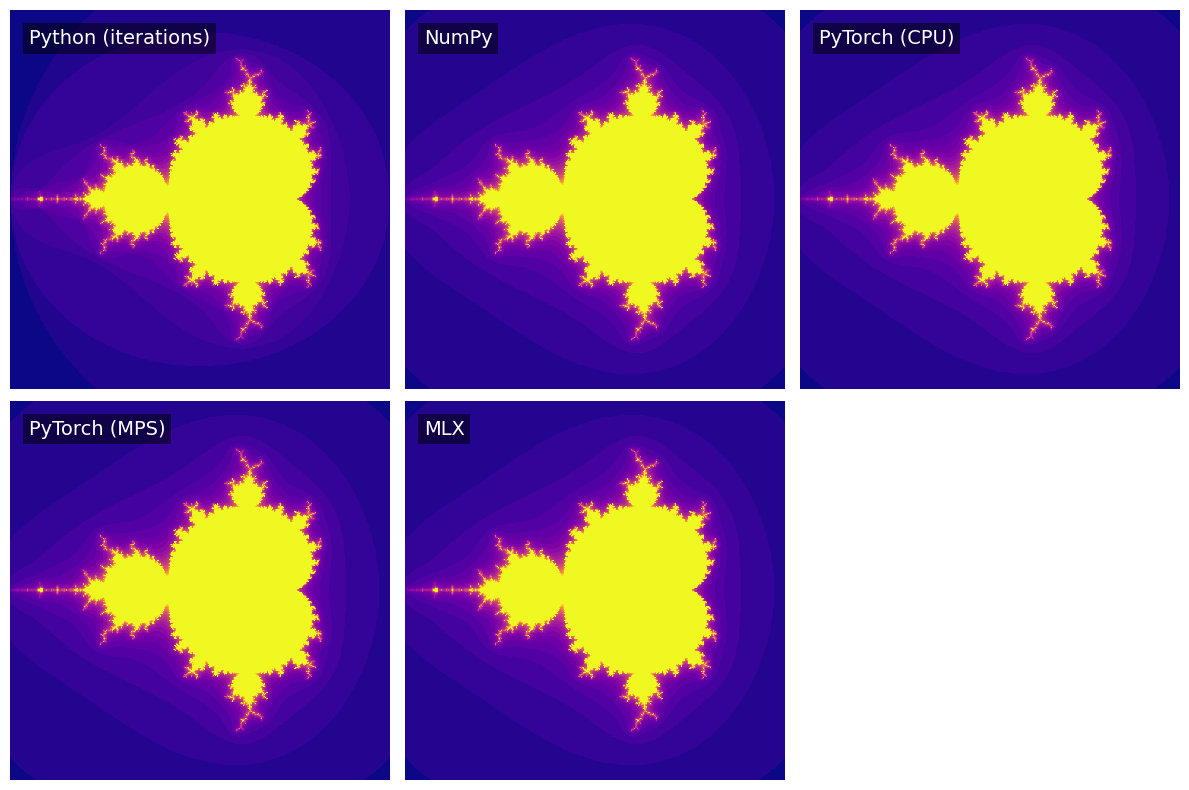

In [7]:
plot_mandelbrot_grid(
    iter_counts,
    titles=[
        "Python (iterations)",
        "NumPy",
        "PyTorch (CPU)",
        "PyTorch (MPS)" if mps_available else None, "MLX"
    ]
)

That confirms that each of the methods above is correct, and that they all yild the same result. The only difference is the speed at which they compute the Mandelbrot set!

## Timing the functions

So we can easily contrast and compare the speed of each of the above functions, let's time them using the `time` module in Python at different resolutions (width and height). We will see the difference in parallelism between methods which rely entirely on the CPU and those which offload the computation to the GPU. All timings are in seconds.

In [8]:
import time

resolutions = [1000, 2000, 3000, 4000]
max_iter = 1000

header = [
    "Resolution",
    "Iterations",
    "NumPy",
    "PyTorch/cpu",
    "PyTorch/mps", 
    "MLX"
]

table_data = []

for n in resolutions:
    width = height = n
    timings = {}
    
    start_time = time.time()
    compute_mandelbrot_iterations(width, height, max_iter)
    timings["Iterations"] = time.time() - start_time

    start_time = time.time()
    compute_mandelbrot_numpy(width, height, max_iter)
    timings["NumPy"] = time.time() - start_time

    start_time = time.time()
    compute_mandelbrot_torch(width, height, max_iter, "cpu")
    timings["PyTorch/cpu"] = time.time() - start_time

    if mps_available:
        start_time = time.time()
        compute_mandelbrot_torch(width, height, max_iter, "mps")
        timings["PyTorch/mps"] = time.time() - start_time
    else:
        timings["PyTorch/mps"] = None

    start_time = time.time()
    compute_mandelbrot_mlx(width, height, max_iter)
    timings["MLX"] = time.time() - start_time

    row = [
        f"{n}x{n}",
        f"{timings['Iterations']:.3f}",
        f"{timings['NumPy']:.3f}",
        f"{timings['PyTorch/cpu']:.3f}",
        f"{timings['PyTorch/mps']:.3f}" if timings['PyTorch/mps'] is not None else "N/A",
        f"{timings['MLX']:.3f}"
    ]
    table_data.append(row)

print("{:<12} {:<12} {:<12} {:<15} {:<15} {:<12}".format(*header))
for row in table_data:
    print("{:<12} {:<12} {:<12} {:<15} {:<15} {:<12}".format(*row))

Resolution   Iterations   NumPy        PyTorch/cpu     PyTorch/mps     MLX         
1000x1000    18.288       5.339        2.922           0.546           0.408       
2000x2000    72.195       26.356       5.846           1.644           1.448       
3000x3000    163.539      67.234       19.148          3.147           2.941       
4000x4000    298.324      117.985      61.559          5.184           4.948       


And finally let us put the above results in an intuitive visual representation, so we can see the difference in speed between the different methods.

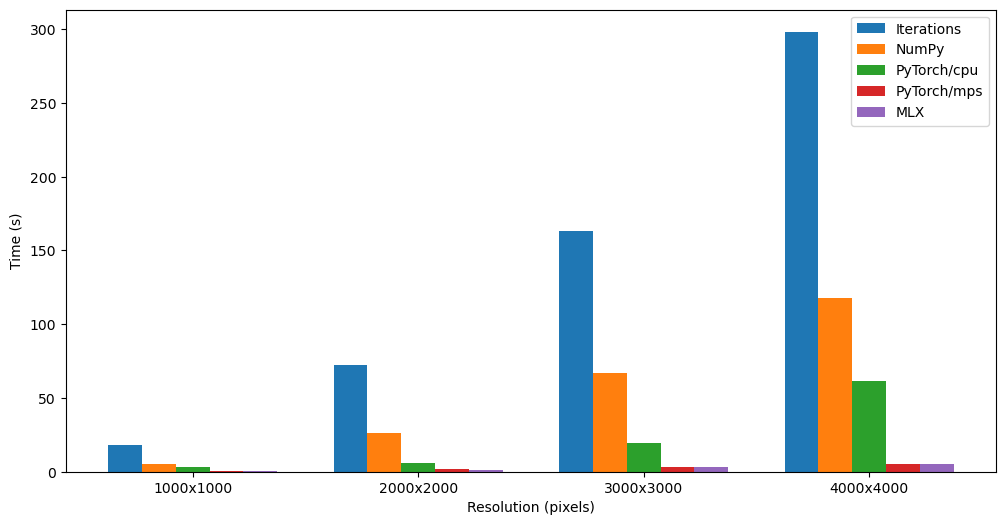

In [9]:
import matplotlib.ticker as ticker

resolutions_numeric = [int(row[0].split('x')[0]) for row in table_data]
methods = header[1:]

num_res = len(resolutions_numeric)
num_methods = len(methods)
x = np.arange(num_res)  # x locations for the groups
width = 0.15            # width of each bar

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for each method
for i, method in enumerate(methods):
    times = []
    for row in table_data:
        value = row[i+1]  # skip the resolution column
        # Use 0 for "N/A", or you could choose to skip/handle it differently
        times.append(float(value) if value != "N/A" else 0)
    # Calculate offset for each method within the group
    offset = (i - num_methods/2) * width + width/2
    ax.bar(x + offset, times, width, label=method)

# Set labels and ticks
ax.set_xlabel("Resolution (pixels)")
ax.set_ylabel("Time (s)")
ax.set_xticks(x)
ax.set_xticklabels([f"{res}x{res}" for res in resolutions_numeric])

# Disable scientific notation on the y-axis
formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)

ax.legend()
plt.show()


You can see that the GPU methods are significantly faster than the CPU methods because of its parallelism. The more cores you have, the faster the computation will be. This is why GPUs are so good at parallel workloads, and why they are so good at machine learning and AI workloads - deep down, they are just matrix operations using embarrasingly parallel workloads.